# Tissue Clocks: hands-on notebook

MICCAI Educational Challenge 2026 minicourse companion notebook.

This notebook reproduces every real number and figure from the [course site](https://ryanwangk.github.io/tissue-clocks-minicourse/) end to end: **fetch → load → split → train → evaluate → interpret**. No GPU required; everything here runs on Colab's free CPU runtime in a couple of minutes.

- Course site: https://ryanwangk.github.io/tissue-clocks-minicourse/
- Course repository: https://github.com/ryanwangk/tissue-clocks-minicourse
- Paper: Abila, Buljan, Zheng et al., Rendeiro, A. F. "Histological aging signatures for monitoring tissue-specific aging and disease." *Nature Medicine* (2026). [doi:10.1038/s41591-026-04566-5](https://doi.org/10.1038/s41591-026-04566-5)
- Embeddings: [Zenodo 10.5281/zenodo.20709093](https://doi.org/10.5281/zenodo.20709093)


## 1. Setup

`anndata` isn't preinstalled on Colab; everything else (`scikit-learn`, `pandas`, `numpy`, `matplotlib`) already is. We pin `pandas==2.2.3` on install to match Colab's own `google-colab` package, which is pinned to that exact version; an unconstrained `pip install anndata` otherwise pulls in a newer pandas and fights that pin.

In [1]:
!pip install -q anndata "pandas==2.2.3"


## 2. Fetch the real embeddings

We use the exact CONCH embedding file the tissue-clocks paper's own authors published: `gtex.4_tissues.0.5mpp.224px.conch.h5ad`, openly archived on Zenodo, no login required. It's 10.6 MB, a 512-dimensional CONCH embedding per slide, already mean-pooled from thousands of tiles, for 4,791 slides across 6 tissues. Running CONCH itself over the raw gigapixel slides is what this file lets us skip; see Section 04 of the course site for why.

In [2]:
!curl -sL -o gtex.4_tissues.0.5mpp.224px.conch.h5ad "https://zenodo.org/records/20709093/files/gtex.4_tissues.0.5mpp.224px.conch.h5ad?download=1"
!ls -lh gtex.4_tissues.0.5mpp.224px.conch.h5ad


-rw-r--r--@ 1 ryanwk  staff    10M Aug 19 21:11 gtex.4_tissues.0.5mpp.224px.conch.h5ad


## 3. Load and explore

In [3]:
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

adata = ad.read_h5ad("gtex.4_tissues.0.5mpp.224px.conch.h5ad")
print(adata)
print()
print(f"Slides: {adata.n_obs}, embedding dim: {adata.n_vars}")
print(f"Unique donors: {adata.obs['Subject ID'].nunique()}")
adata.obs[["Tissue", "Sex", "Age Bracket", "Hardy Scale"]].head()


AnnData object with n_obs × n_vars = 4791 × 512
    obs: 'Tissue', 'Subject ID', 'Sex', 'Age Bracket', 'Hardy Scale', 'Pathology Categories', 'Pathology Notes'

Slides: 4791, embedding dim: 512
Unique donors: 971


,Tissue,Sex,Age Bracket,Hardy Scale
GTEX-1117F-0126,Skin - Sun Exposed (Lower leg),female,60-69,Slow death
GTEX-1117F-1026,Lung,female,60-69,Slow death
GTEX-1117F-2326,Colon - Sigmoid,female,60-69,Slow death
GTEX-1117F-2726,Colon - Transverse,female,60-69,Slow death
GTEX-1117F-2926,Skin - Not Sun Exposed (Suprapubic),female,60-69,Slow death


Two quick sanity-check figures before we train anything: how many slides per tissue, and how skewed the age distribution is (both shown on the course site, Section 05).

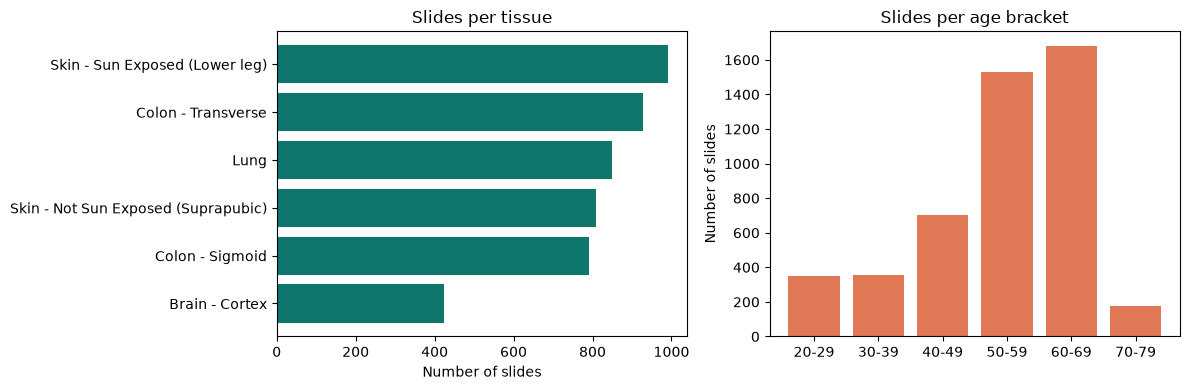

In [4]:
TEAL = "#0f766e"
CORAL = "#e07856"
NEUTRAL = "#94a3b8"
BRACKET_ORDER = ["20-29", "30-39", "40-49", "50-59", "60-69", "70-79"]
BRACKET_MIDPOINT = {"20-29": 25, "30-39": 35, "40-49": 45, "50-59": 55, "60-69": 65, "70-79": 75}

obs = adata.obs.copy()
X_all = adata.X

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = obs["Tissue"].value_counts().sort_values()
axes[0].barh(counts.index, counts.values, color=TEAL)
axes[0].set_xlabel("Number of slides")
axes[0].set_title("Slides per tissue")

age_counts = obs["Age Bracket"].value_counts().reindex(BRACKET_ORDER)
axes[1].bar(age_counts.index, age_counts.values, color=CORAL)
axes[1].set_ylabel("Number of slides")
axes[1].set_title("Slides per age bracket")
plt.tight_layout()
plt.show()


## 4. Split by donor, not by slide

Each donor contributes tissue samples from more than one organ. Splitting by *slide* would let the same donor's tissue appear in both train and test: the model could implicitly memorize a donor's identity across their own samples and report misleadingly good numbers. We split by **donor** instead, so every one of a donor's samples lands entirely on one side.

In [5]:
from sklearn.model_selection import GroupShuffleSplit

RANDOM_STATE = 42
subjects = obs["Subject ID"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X_all, groups=subjects))

print(f"Total slides: {len(obs)}, unique donors: {obs['Subject ID'].nunique()}")
print(f"Train slides: {len(train_idx)} ({obs.iloc[train_idx]['Subject ID'].nunique()} donors)")
print(f"Test slides:  {len(test_idx)} ({obs.iloc[test_idx]['Subject ID'].nunique()} donors)")


Total slides: 4791, unique donors: 971
Train slides: 3832 (776 donors)
Test slides:  959 (195 donors)


## 5. Train one model per tissue

We train a separate `HistGradientBoostingClassifier` per tissue, matching the paper's own tissue-specific framing: a "tissue clock," not one clock for every organ. Each model predicts a slide's age bracket from nothing but its 512-dim CONCH embedding.

In [6]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, mean_absolute_error

results = {"per_tissue": {}, "pooled": {}}

for tissue in sorted(obs["Tissue"].unique()):
    tissue_mask = (obs["Tissue"] == tissue).values
    tr_idx = np.intersect1d(train_idx, np.where(tissue_mask)[0])
    te_idx = np.intersect1d(test_idx, np.where(tissue_mask)[0])

    if len(tr_idx) < 20 or len(te_idx) < 5:
        print(f"[{tissue}] skipped: too few samples")
        continue

    X_tr, X_te = X_all[tr_idx], X_all[te_idx]
    y_tr = obs.iloc[tr_idx]["Age Bracket"].values
    y_te = obs.iloc[te_idx]["Age Bracket"].values

    clf = HistGradientBoostingClassifier(random_state=RANDOM_STATE, max_iter=200)
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)

    acc = accuracy_score(y_te, y_pred)
    bal_acc = balanced_accuracy_score(y_te, y_pred)
    mae_years = mean_absolute_error(
        [BRACKET_MIDPOINT[b] for b in y_te], [BRACKET_MIDPOINT[b] for b in y_pred]
    )
    majority_bracket = pd.Series(y_tr).mode()[0]
    baseline_mae = mean_absolute_error(
        [BRACKET_MIDPOINT[b] for b in y_te], [BRACKET_MIDPOINT[majority_bracket]] * len(y_te)
    )

    results["per_tissue"][tissue] = {
        "n_train": int(len(tr_idx)), "n_test": int(len(te_idx)),
        "accuracy": round(float(acc), 4), "balanced_accuracy": round(float(bal_acc), 4),
        "mae_years": round(float(mae_years), 2), "baseline_mae_years": round(float(baseline_mae), 2),
        "majority_bracket": majority_bracket,
    }
    print(f"[{tissue:38s}] n_train={len(tr_idx):4d} n_test={len(te_idx):3d} "
          f"MAE={mae_years:5.2f}yr  (baseline={baseline_mae:5.2f}yr)")


[Brain - Cortex                        ] n_train= 337 n_test= 86 MAE= 7.44yr  (baseline= 7.33yr)


[Colon - Sigmoid                       ] n_train= 633 n_test=159 MAE=10.00yr  (baseline=13.27yr)


[Colon - Transverse                    ] n_train= 740 n_test=188 MAE= 9.26yr  (baseline=13.24yr)


[Lung                                  ] n_train= 681 n_test=169 MAE= 7.93yr  (baseline=12.13yr)


[Skin - Not Sun Exposed (Suprapubic)   ] n_train= 646 n_test=162 MAE= 8.33yr  (baseline=12.90yr)


[Skin - Sun Exposed (Lower leg)        ] n_train= 795 n_test=195 MAE= 7.79yr  (baseline=13.18yr)


## 6. Train the pooled model

For the confusion matrix and the clinical sanity-check later, we also train one model across all six tissues together, with tissue itself as a one-hot feature.

In [7]:
tissue_dummies = pd.get_dummies(obs["Tissue"], prefix="tissue")
X_pooled = np.hstack([X_all, tissue_dummies.values])
X_tr, X_te = X_pooled[train_idx], X_pooled[test_idx]
y_tr = obs.iloc[train_idx]["Age Bracket"].values
y_te = obs.iloc[test_idx]["Age Bracket"].values

pooled_clf = HistGradientBoostingClassifier(random_state=RANDOM_STATE, max_iter=300)
pooled_clf.fit(X_tr, y_tr)
y_pred_pooled = pooled_clf.predict(X_te)

acc = accuracy_score(y_te, y_pred_pooled)
bal_acc = balanced_accuracy_score(y_te, y_pred_pooled)
mae_years = mean_absolute_error(
    [BRACKET_MIDPOINT[b] for b in y_te], [BRACKET_MIDPOINT[b] for b in y_pred_pooled]
)
majority_bracket = pd.Series(y_tr).mode()[0]
baseline_mae = mean_absolute_error(
    [BRACKET_MIDPOINT[b] for b in y_te], [BRACKET_MIDPOINT[majority_bracket]] * len(y_te)
)
results["pooled"] = {
    "n_train": int(len(train_idx)), "n_test": int(len(test_idx)),
    "accuracy": round(float(acc), 4), "balanced_accuracy": round(float(bal_acc), 4),
    "mae_years": round(float(mae_years), 2), "baseline_mae_years": round(float(baseline_mae), 2),
    "majority_bracket": majority_bracket,
}
print(f"[POOLED, all tissues] n_train={len(train_idx)} n_test={len(test_idx)} "
      f"MAE={mae_years:.2f}yr (baseline={baseline_mae:.2f}yr)")


[POOLED, all tissues] n_train=3832 n_test=959 MAE=8.47yr (baseline=12.45yr)


## 7. Evaluate: MAE vs. a naive baseline

The baseline always predicts the majority age bracket seen in training. Beating it means the model is picking up real signal from tissue structure, not just guessing the most common answer.

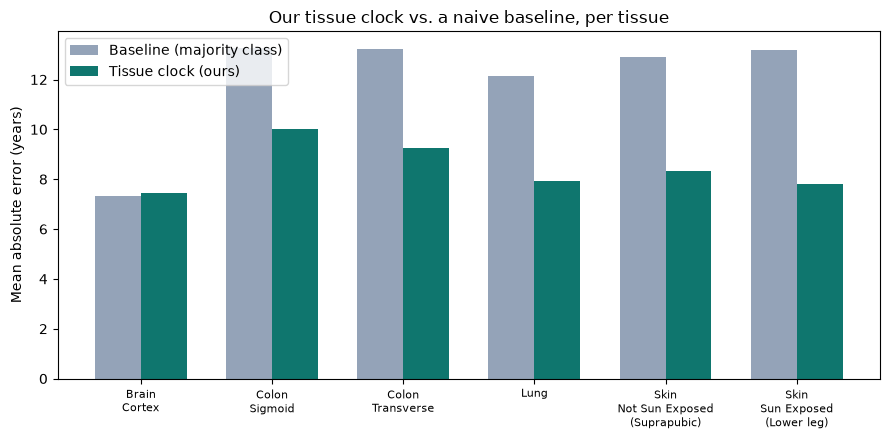

Brain - Cortex                         does NOT beat baseline  (7.44yr vs 7.33yr)
Colon - Sigmoid                        beats baseline  (10.0yr vs 13.27yr)
Colon - Transverse                     beats baseline  (9.26yr vs 13.24yr)
Lung                                   beats baseline  (7.93yr vs 12.13yr)
Skin - Not Sun Exposed (Suprapubic)    beats baseline  (8.33yr vs 12.9yr)
Skin - Sun Exposed (Lower leg)         beats baseline  (7.79yr vs 13.18yr)


In [8]:
tissues = list(results["per_tissue"].keys())
mae = [results["per_tissue"][t]["mae_years"] for t in tissues]
baseline = [results["per_tissue"][t]["baseline_mae_years"] for t in tissues]
short_names = [t.replace(" - ", "\n").replace(" (", "\n(") for t in tissues]

x = np.arange(len(tissues))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(x - width/2, baseline, width, label="Baseline (majority class)", color=NEUTRAL)
ax.bar(x + width/2, mae, width, label="Tissue clock (ours)", color=TEAL)
ax.set_ylabel("Mean absolute error (years)")
ax.set_title("Our tissue clock vs. a naive baseline, per tissue")
ax.set_xticks(x)
ax.set_xticklabels(short_names, fontsize=8)
ax.legend()
plt.tight_layout()
plt.show()

for t in tissues:
    r = results["per_tissue"][t]
    beat = "beats" if r["mae_years"] < r["baseline_mae_years"] else "does NOT beat"
    print(f"{t:38s} {beat} baseline  ({r['mae_years']}yr vs {r['baseline_mae_years']}yr)")


## 8. Evaluate: confusion matrix

Row-normalized: each row (one true age bracket) sums to 1.0, so a cell reads as "of the slides that were actually this age, what fraction did the pooled model predict as that age."

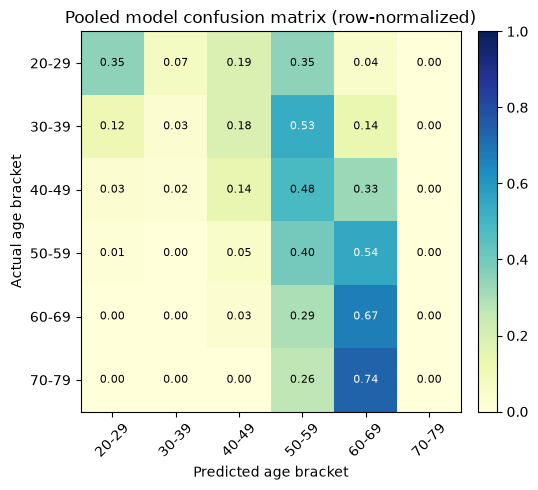

In [9]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_te, y_pred_pooled, labels=BRACKET_ORDER)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(cm_norm, cmap="YlGnBu", vmin=0, vmax=1)
ax.set_xticks(range(len(BRACKET_ORDER))); ax.set_yticks(range(len(BRACKET_ORDER)))
ax.set_xticklabels(BRACKET_ORDER, rotation=45); ax.set_yticklabels(BRACKET_ORDER)
ax.set_xlabel("Predicted age bracket"); ax.set_ylabel("Actual age bracket")
ax.set_title("Pooled model confusion matrix (row-normalized)")
for i in range(len(BRACKET_ORDER)):
    for j in range(len(BRACKET_ORDER)):
        ax.text(j, i, f"{cm_norm[i,j]:.2f}", ha="center", va="center",
                 color="white" if cm_norm[i, j] > 0.5 else "black", fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## 9. Interpret: does the age gap mean anything clinically?

We never trained on Hardy Scale (the classification of how each donor died); it's held in reserve purely to sanity-check whether the model's predicted age gap (predicted age &minus; chronological age) lines up with anything clinically meaningful.

/var/folders/_x/xkyl2_7x1zvgxfyvqg2c1sqm0000gn/T/ipykernel_60907/1423879994.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gap_by_hardy = test_obs.groupby("Hardy Scale")["age_gap_years"].agg(["mean", "std", "count"]).reindex(hardy_order)


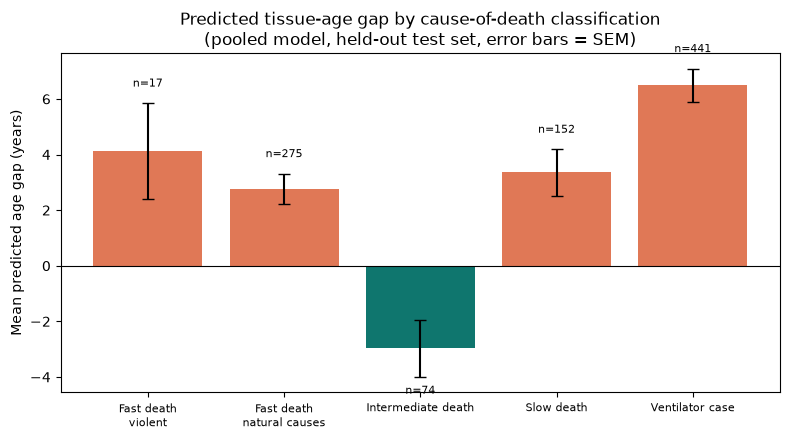

,mean,std,count
Hardy Scale,,,
Fast death - violent,4.117647,7.122871,17
Fast death - natural causes,2.763636,9.021393,275
Intermediate death,-2.972973,8.871955,74
Slow death,3.355263,10.225541,152
Ventilator case,6.485261,12.617822,441


In [10]:
test_obs = obs.iloc[test_idx].copy()
test_obs["predicted_bracket"] = y_pred_pooled
test_obs["actual_midpoint"] = test_obs["Age Bracket"].astype(str).map(BRACKET_MIDPOINT).astype(float)
test_obs["predicted_midpoint"] = pd.Series(test_obs["predicted_bracket"]).astype(str).map(BRACKET_MIDPOINT).astype(float).values
test_obs["age_gap_years"] = test_obs["predicted_midpoint"] - test_obs["actual_midpoint"]

hardy_order = ["Fast death - violent", "Fast death - natural causes",
               "Intermediate death", "Slow death", "Ventilator case"]
gap_by_hardy = test_obs.groupby("Hardy Scale")["age_gap_years"].agg(["mean", "std", "count"]).reindex(hardy_order)
sem = gap_by_hardy["std"] / np.sqrt(gap_by_hardy["count"])

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = [CORAL if m > 0 else TEAL for m in gap_by_hardy["mean"]]
ax.bar(range(len(hardy_order)), gap_by_hardy["mean"], yerr=sem, color=colors, capsize=4)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(range(len(hardy_order)))
ax.set_xticklabels([h.replace(" - ", "\n") for h in hardy_order], fontsize=8)
ax.set_ylabel("Mean predicted age gap (years)")
ax.set_title("Predicted tissue-age gap by cause-of-death classification\n(pooled model, held-out test set, error bars = SEM)")
for i, (m, c, s) in enumerate(zip(gap_by_hardy["mean"], gap_by_hardy["count"], sem)):
    offset = s + 0.6
    y = m + offset if m > 0 else m - offset
    ax.text(i, y, f"n={int(c)}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

gap_by_hardy


## Recap

- We fetched real, pre-extracted CONCH slide embeddings, no CONCH inference and no GPU required.
- Splitting by **donor** (not slide) prevents leakage across a donor's multiple tissue samples.
- Five of six tissues clearly beat a naive baseline; Brain-Cortex doesn't, mainly because it has the fewest training examples of any tissue here; see Section 07 of the course site for the full discussion.
- The model's predicted age gap correlates with Hardy Scale even though it was never trained on it, echoing the kind of clinical-relevance finding the original paper reports.

Course site: https://ryanwangk.github.io/tissue-clocks-minicourse/
